# Monte Carlo-валидация WLS относительно условной CRLB

Этот notebook сравнивает WLS и условную CRLB без генерации аудиосигнала, GCC-PHAT и SRP-PHAT. Используются две различные модели ошибок:

1. **Независимые измеренные TDOA:** $\eta\sim\mathcal N(0,\sigma_{\mathrm{tdoa}}^2 I)$.
2. **Независимые TOA:** $e_m\sim\mathcal N(0,\sigma_{\mathrm{toa}}^2)$ и $\Sigma_{\mathrm{tdoa}}=B\Sigma_{\mathrm{toa}}B^T$.

Опорные $M-1$ TDOA линейно независимы, но во второй модели статистически коррелированы. Для marginal standard deviation одной разности 50 мкс принято $\sigma_{\mathrm{toa}}=50/\sqrt{2}$ мкс. Квадратная решётка рассматривается условно на известной верхней полусфере и остаётся зеркально неоднозначной.

In [1]:
from pathlib import Path
import csv
import platform
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

project_root = Path.cwd()
if not (project_root / 'model').is_dir():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from validation.study import (
    ARRAY_NAMES, BASE_SEED, DIRECTIONS_DEG, EXPECTED_CONFIGURATION_COUNT,
    LOW_NOISE_MAX_COORDINATE_BIAS_Z, LOW_NOISE_NORMALIZED_COVARIANCE_RANGE,
    LOW_NOISE_RATIO_RANGE, SIGMA_TDOA_US, SIGMA_TOA_US, run_validation_study,
)

N_TRIALS = 2000
OUTPUT_CSV = project_root / 'results' / 'monte_carlo_crlb_summary.csv'
print('Python:', platform.python_version())
print('NumPy:', np.__version__, 'Matplotlib:', matplotlib.__version__)
print('seed:', BASE_SEED, 'trials/configuration:', N_TRIALS)
print('sigma_toa for 50 us marginal TDOA:', SIGMA_TOA_US, 'us')

Python: 3.11.7
NumPy: 2.4.6 Matplotlib: 3.11.1
seed: 20260827 trials/configuration: 2000
sigma_toa for 50 us marginal TDOA: 35.35533905932737 us


## Выполнение 84 000 WLS-оценок

Для каждой решётки используются три заданных направления, шесть уровней $\sigma_{\mathrm{tdoa}}$ и отдельная TOA-индуцированная конфигурация. Результаты агрегируются без отбрасывания неуспешных оптимизаций.

In [2]:
records = run_validation_study(n_trials=N_TRIALS, output_csv=OUTPUT_CSV)
print('configurations:', len(records))
print('total WLS trials:', sum(int(row['n_trials']) for row in records))
print('CSV:', OUTPUT_CSV)

def select_rows(*, array=None, direction_id=None, noise_model=None, marginal_std=None):
    selected = records
    if array is not None:
        selected = [row for row in selected if row['array'] == array]
    if direction_id is not None:
        selected = [row for row in selected if row['direction_id'] == direction_id]
    if noise_model is not None:
        selected = [row for row in selected if row['noise_model'] == noise_model]
    if marginal_std is not None:
        selected = [row for row in selected if np.isclose(row['marginal_tdoa_std_us'], marginal_std)]
    return sorted(selected, key=lambda row: float(row['marginal_tdoa_std_us']))

DIRECTION_IDS = [f'az{az:g}_el{el:g}' for az, el in DIRECTIONS_DEG]

configurations: 42
total WLS trials: 84000
CSV: C:\Users\leo\Documents\Stu\APM\7sem\diploma\uav_acoustic_model\results\monte_carlo_crlb_summary.csv


## RMSE и CRLB от уровня независимой TDOA-ошибки

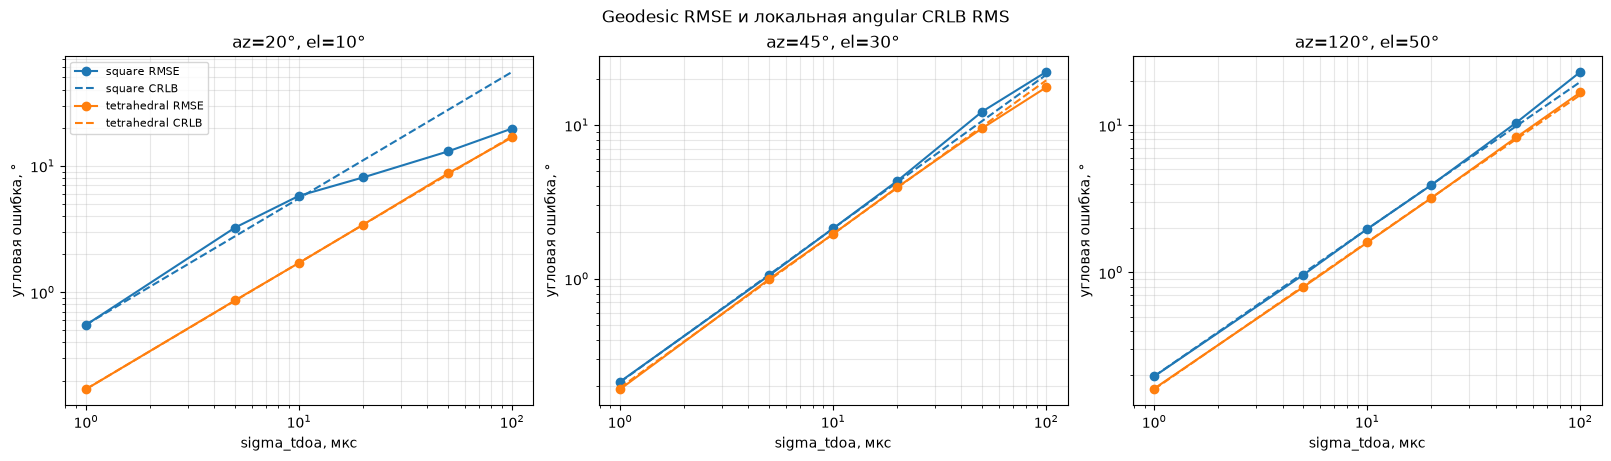

In [3]:
colors = {'square': 'tab:blue', 'tetrahedral': 'tab:orange'}
figure, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
for axis, direction_id, direction in zip(axes, DIRECTION_IDS, DIRECTIONS_DEG):
    for array_name in ARRAY_NAMES:
        rows = select_rows(array=array_name, direction_id=direction_id, noise_model='independent_tdoa')
        sigma = [row['sigma_tdoa_us'] for row in rows]
        axis.loglog(sigma, [row['geodesic_rmse_deg'] for row in rows], 'o-', color=colors[array_name], label=f'{array_name} RMSE')
        axis.loglog(sigma, [row['angular_crlb_rms_deg'] for row in rows], '--', color=colors[array_name], label=f'{array_name} CRLB')
    axis.set_title(f'az={direction[0]:g}°, el={direction[1]:g}°')
    axis.set_xlabel('sigma_tdoa, мкс')
    axis.set_ylabel('угловая ошибка, °')
    axis.grid(True, which='both', alpha=0.3)
axes[0].legend(fontsize=8)
figure.suptitle('Geodesic RMSE и локальная angular CRLB RMS')
plt.show()

## Отношение RMSE/CRLB

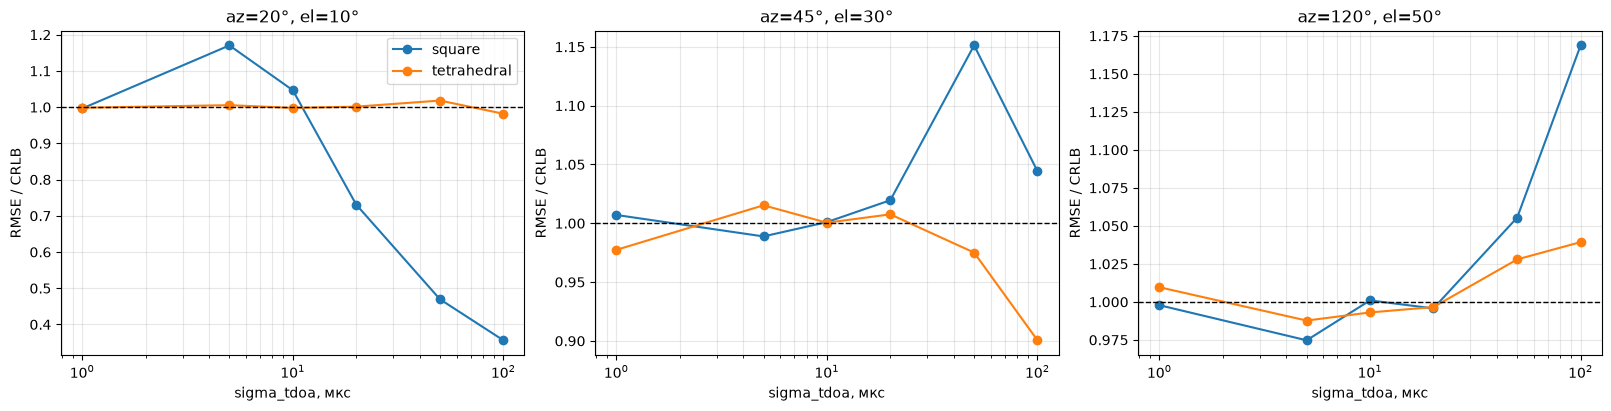

In [4]:
figure, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
for axis, direction_id, direction in zip(axes, DIRECTION_IDS, DIRECTIONS_DEG):
    for array_name in ARRAY_NAMES:
        rows = select_rows(array=array_name, direction_id=direction_id, noise_model='independent_tdoa')
        axis.semilogx([row['sigma_tdoa_us'] for row in rows], [row['rmse_to_crlb_ratio'] for row in rows], 'o-', color=colors[array_name], label=array_name)
    axis.axhline(1.0, color='black', linewidth=1, linestyle='--')
    axis.set_title(f'az={direction[0]:g}°, el={direction[1]:g}°')
    axis.set_xlabel('sigma_tdoa, мкс')
    axis.set_ylabel('RMSE / CRLB')
    axis.grid(True, which='both', alpha=0.3)
axes[0].legend()
plt.show()

## Bias азимута и угла места

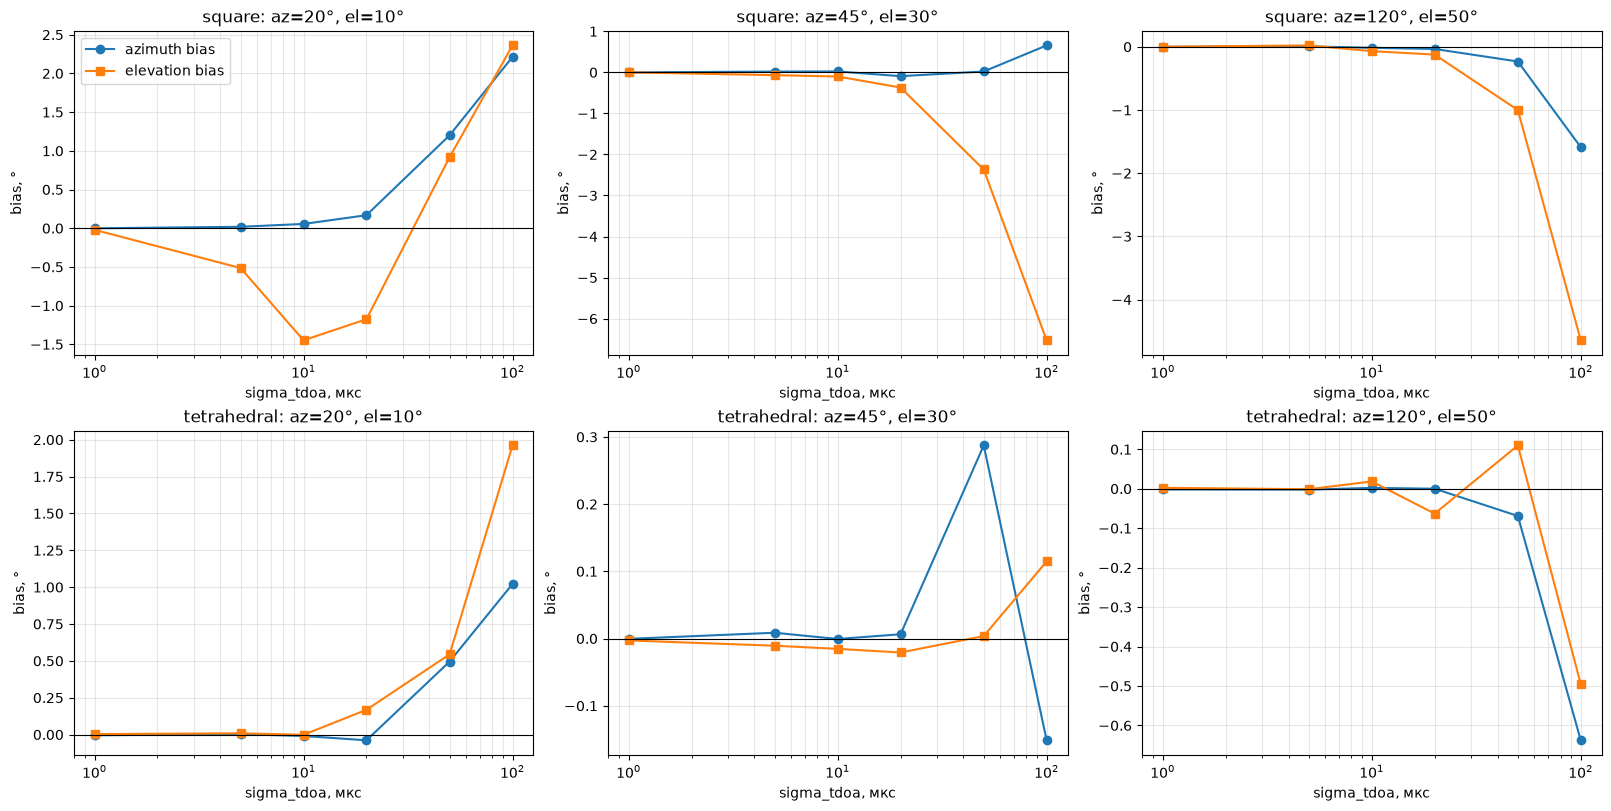

In [5]:
figure, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)
for row_index, array_name in enumerate(ARRAY_NAMES):
    for column_index, (direction_id, direction) in enumerate(zip(DIRECTION_IDS, DIRECTIONS_DEG)):
        axis = axes[row_index, column_index]
        rows = select_rows(array=array_name, direction_id=direction_id, noise_model='independent_tdoa')
        sigma = [row['sigma_tdoa_us'] for row in rows]
        axis.semilogx(sigma, [row['bias_azimuth_deg'] for row in rows], 'o-', label='azimuth bias')
        axis.semilogx(sigma, [row['bias_elevation_deg'] for row in rows], 's-', label='elevation bias')
        axis.axhline(0.0, color='black', linewidth=0.8)
        axis.set_title(f'{array_name}: az={direction[0]:g}°, el={direction[1]:g}°')
        axis.set_xlabel('sigma_tdoa, мкс')
        axis.set_ylabel('bias, °')
        axis.grid(True, which='both', alpha=0.3)
axes[0, 0].legend()
plt.show()

## P95 геодезической ошибки

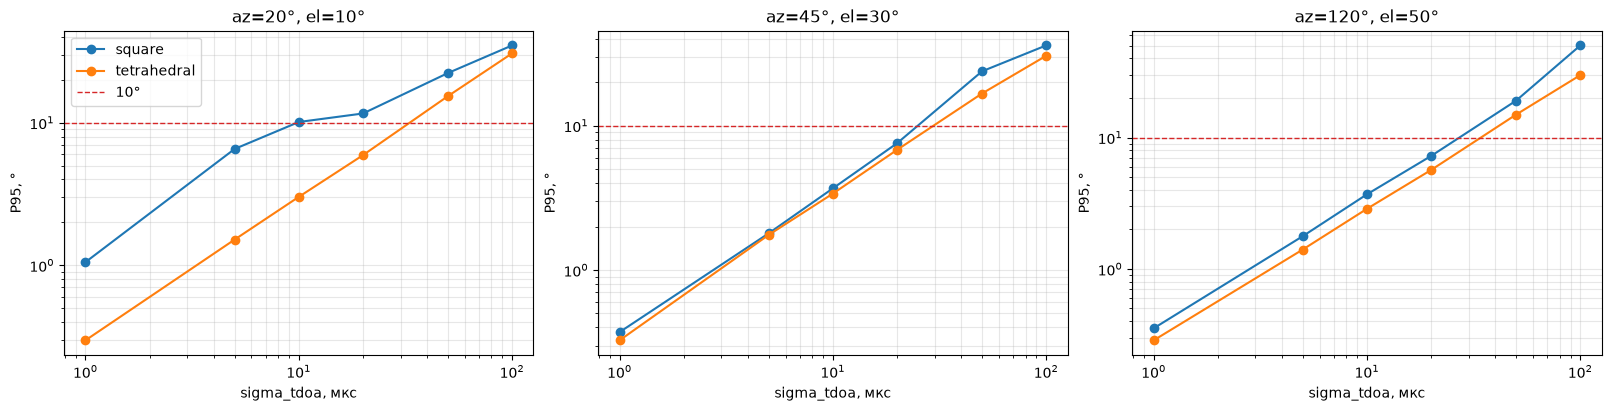

In [6]:
figure, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
for axis, direction_id, direction in zip(axes, DIRECTION_IDS, DIRECTIONS_DEG):
    for array_name in ARRAY_NAMES:
        rows = select_rows(array=array_name, direction_id=direction_id, noise_model='independent_tdoa')
        axis.loglog([row['sigma_tdoa_us'] for row in rows], [row['p95_geodesic_error_deg'] for row in rows], 'o-', color=colors[array_name], label=array_name)
    axis.axhline(10.0, color='tab:red', linestyle='--', linewidth=1, label='10°')
    axis.set_title(f'az={direction[0]:g}°, el={direction[1]:g}°')
    axis.set_xlabel('sigma_tdoa, мкс')
    axis.set_ylabel('P95, °')
    axis.grid(True, which='both', alpha=0.3)
axes[0].legend()
plt.show()

## Независимые TDOA и TOA-индуцированная ковариация при marginal std = 50 мкс

Одинаковая marginal variance отдельной разности не означает одинаковую Fisher information: корреляция меняет вес доступных контрастов.

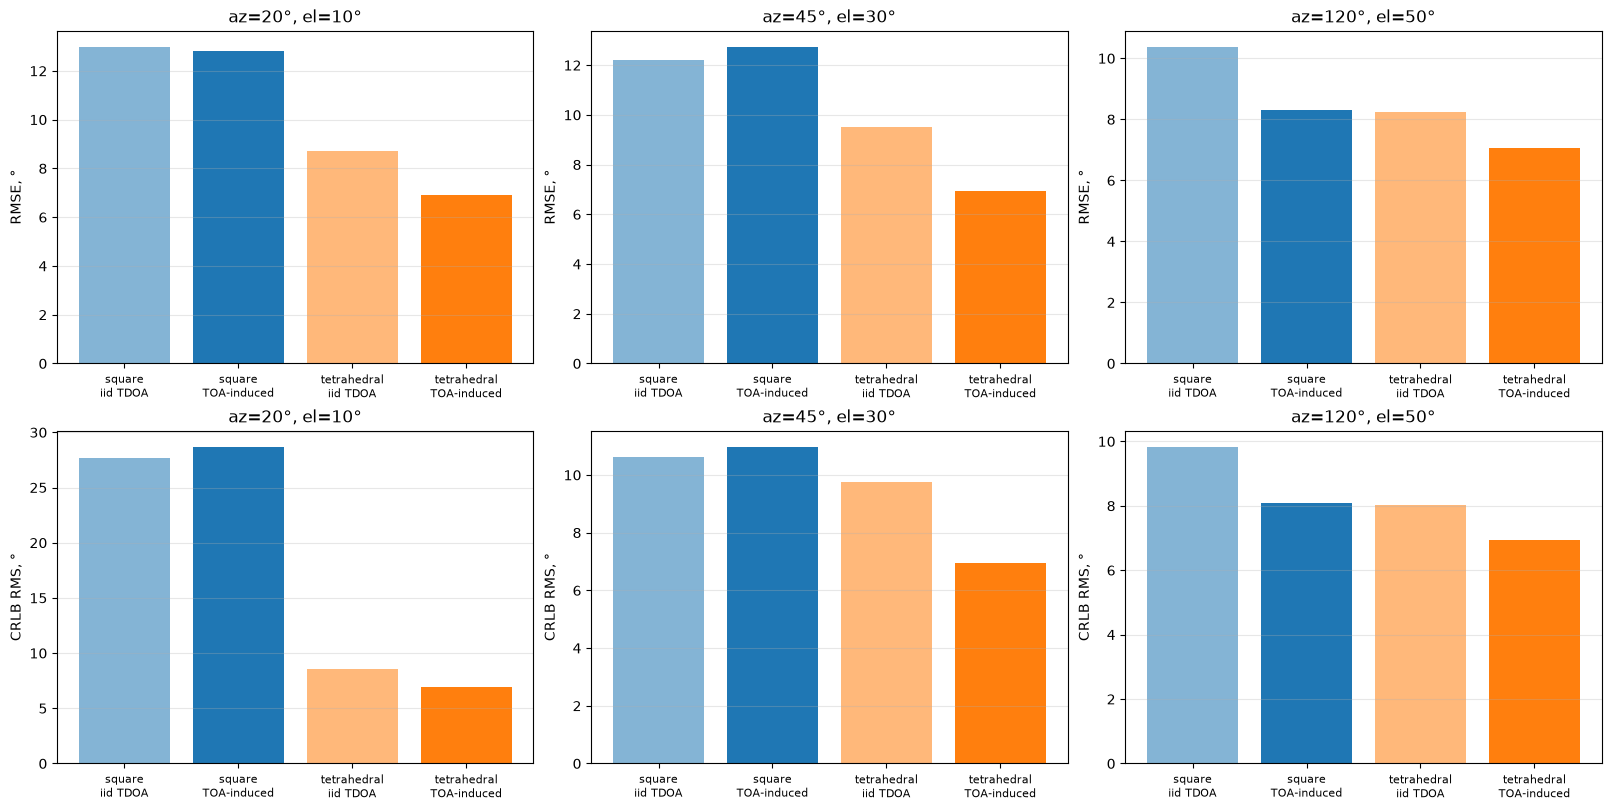

In [7]:
figure, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)
for column, (direction_id, direction) in enumerate(zip(DIRECTION_IDS, DIRECTIONS_DEG)):
    for row_index, metric in enumerate(['geodesic_rmse_deg', 'angular_crlb_rms_deg']):
        labels, values, bar_colors = [], [], []
        for array_name in ARRAY_NAMES:
            iid = select_rows(array=array_name, direction_id=direction_id, noise_model='independent_tdoa', marginal_std=50.0)[0]
            toa = select_rows(array=array_name, direction_id=direction_id, noise_model='independent_toa')[0]
            labels.extend([f'{array_name}\niid TDOA', f'{array_name}\nTOA-induced'])
            values.extend([iid[metric], toa[metric]])
            bar_colors.extend([colors[array_name], colors[array_name]])
        axis = axes[row_index, column]
        bars = axis.bar(range(len(values)), values, color=bar_colors)
        for bar, alpha in zip(bars, [0.55, 1.0, 0.55, 1.0]):
            bar.set_alpha(alpha)
        axis.set_xticks(range(len(values)), labels, fontsize=8)
        axis.set_ylabel('RMSE, °' if row_index == 0 else 'CRLB RMS, °')
        axis.set_title(f'az={direction[0]:g}°, el={direction[1]:g}°')
        axis.grid(True, axis='y', alpha=0.3)
plt.show()

## Численный анализ и критерии

In [8]:
low_noise = [row for row in records if row['low_noise_overall_pass'] is not None]
low_noise_lines = [
    '| array | direction | RMSE/CRLB | eig(Q) min/max | bias z max | result |',
    '|---|---|---:|---:|---:|---|',
]
for row in low_noise:
    low_noise_lines.append(
        f"| {row['array']} | {row['direction_id']} | {row['rmse_to_crlb_ratio']:.3f} | "
        f"{row['normalized_cov_eigenvalue_min']:.3f}/{row['normalized_cov_eigenvalue_max']:.3f} | "
        f"{max(row['bias_z_azimuth'], row['bias_z_elevation']):.3f} | "
        f"{'PASS' if row['low_noise_overall_pass'] else 'FAIL'} |"
    )
display(Markdown('### Малый шум: sigma_tdoa = 1 мкс\n\n' + '\n'.join(low_noise_lines)))

high_noise = [row for row in records if row['noise_model'] == 'independent_tdoa' and np.isclose(row['sigma_tdoa_us'], 100.0)]
high_noise_lines = [
    '| array | direction | bias, ° | RMSE, ° | CRLB, ° | ratio | boundary | >10° |',
    '|---|---|---:|---:|---:|---:|---:|---:|',
]
for row in high_noise:
    high_noise_lines.append(
        f"| {row['array']} | {row['direction_id']} | {row['physical_bias_deg']:.2f} | "
        f"{row['geodesic_rmse_deg']:.2f} | {row['angular_crlb_rms_deg']:.2f} | "
        f"{row['rmse_to_crlb_ratio']:.2f} | {row['boundary_fraction']:.1%} | {row['fraction_over_10deg']:.1%} |"
    )
display(Markdown('### Большой шум: sigma_tdoa = 100 мкс\n\n' + '\n'.join(high_noise_lines)))

### Малый шум: sigma_tdoa = 1 мкс

| array | direction | RMSE/CRLB | eig(Q) min/max | bias z max | result |
|---|---|---:|---:|---:|---|
| square | az20_el10 | 0.996 | 0.990/1.014 | 0.038 | PASS |
| square | az45_el30 | 1.007 | 1.004/1.029 | 0.007 | PASS |
| square | az120_el50 | 0.998 | 0.986/1.011 | 0.004 | PASS |
| tetrahedral | az20_el10 | 0.998 | 0.983/1.017 | 0.036 | PASS |
| tetrahedral | az45_el30 | 0.977 | 0.935/0.977 | 0.021 | PASS |
| tetrahedral | az120_el50 | 1.010 | 0.973/1.039 | 0.018 | PASS |

### Большой шум: sigma_tdoa = 100 мкс

| array | direction | bias, ° | RMSE, ° | CRLB, ° | ratio | boundary | >10° |
|---|---|---:|---:|---:|---:|---:|---:|
| square | az20_el10 | 3.21 | 19.73 | 55.38 | 0.36 | 44.0% | 93.2% |
| square | az45_el30 | 6.55 | 22.17 | 21.23 | 1.04 | 19.1% | 80.3% |
| square | az120_el50 | 4.76 | 23.00 | 19.68 | 1.17 | 7.6% | 73.2% |
| tetrahedral | az20_el10 | 2.20 | 16.80 | 17.11 | 0.98 | 17.9% | 67.5% |
| tetrahedral | az45_el30 | 0.17 | 17.59 | 19.53 | 0.90 | 0.7% | 72.4% |
| tetrahedral | az120_el50 | 0.64 | 16.68 | 16.05 | 1.04 | 0.1% | 65.1% |

In [9]:
required_finite = [
    'geodesic_rmse_deg', 'median_geodesic_error_deg', 'p95_geodesic_error_deg',
    'angular_crlb_rms_deg', 'rmse_to_crlb_ratio', 'bias_azimuth_deg',
    'bias_elevation_deg', 'normalized_cov_eigenvalue_min',
    'normalized_cov_eigenvalue_max',
]
configuration_pass = len(records) == EXPECTED_CONFIGURATION_COUNT
trials_pass = sum(int(row['n_trials']) for row in records) == 84000
finite_pass = all(np.isfinite(float(row[field])) for row in records for field in required_finite)
csv_pass = OUTPUT_CSV.exists() and sum(1 for _ in OUTPUT_CSV.open(encoding='utf-8')) == EXPECTED_CONFIGURATION_COUNT + 1
low_noise_pass = len(low_noise) == 6 and all(bool(row['low_noise_overall_pass']) for row in low_noise)
validation = [
    ('42 конфигурации', configuration_pass),
    ('84 000 WLS-испытаний', trials_pass),
    ('конечность обязательных метрик', finite_pass),
    ('CSV: заголовок + 42 строки', csv_pass),
    ('малошумовое соответствие WLS и CRLB', low_noise_pass),
]
validation_lines = ['| проверка | итог |', '|---|---|'] + [
    f"| {name} | {'PASS' if passed else 'FAIL'} |" for name, passed in validation
]
display(Markdown('### Итоговая проверка\n\n' + '\n'.join(validation_lines)))
assert all(passed for _, passed in validation)

### Итоговая проверка

| проверка | итог |
|---|---|
| 42 конфигурации | PASS |
| 84 000 WLS-испытаний | PASS |
| конечность обязательных метрик | PASS |
| CSV: заголовок + 42 строки | PASS |
| малошумовое соответствие WLS и CRLB | PASS |